# 04 Interpretabilidad

Interpretar el modelo seleccionado para identificar qué variables impulsan el churn y traducir hallazgos técnicos en decisiones estratégicas de negocio.

## 1. Importar librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from xgboost import XGBClassifier

## 2. Cargar datos

In [3]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

## 3. Entrenando modelo

In [4]:
model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [5]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values('Importance', ascending=False)
importance.head(15)

,Feature,Importance
10,10,0.428605
25,25,0.183020
24,24,0.095892
11,11,0.053473
23,23,0.023632
1,1,0.023448
13,13,0.015021
28,28,0.014857
9,9,0.013778
21,21,0.013468


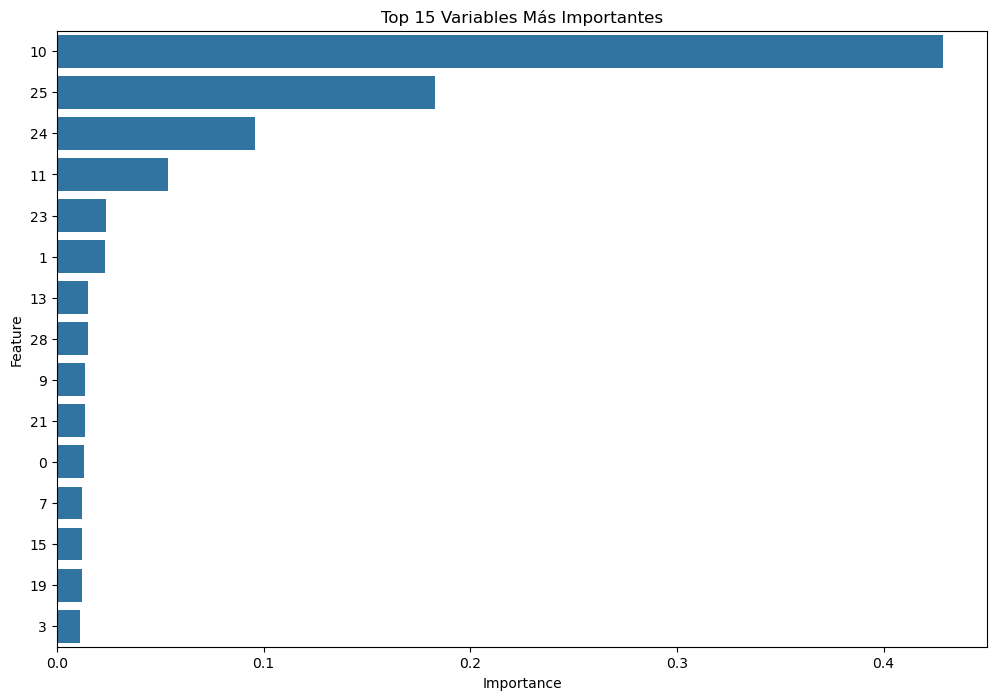

In [6]:
plt.figure(figsize=(12,8))
sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)
plt.title('Top 15 Variables Más Importantes')
plt.show()

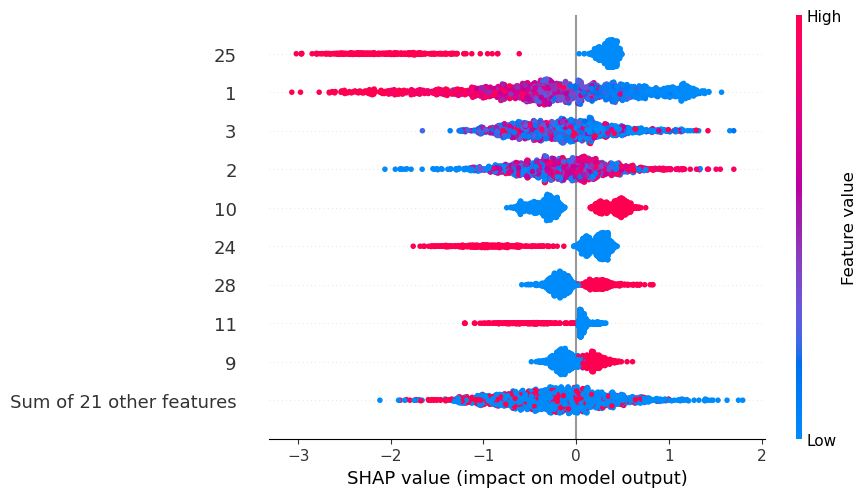

In [11]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

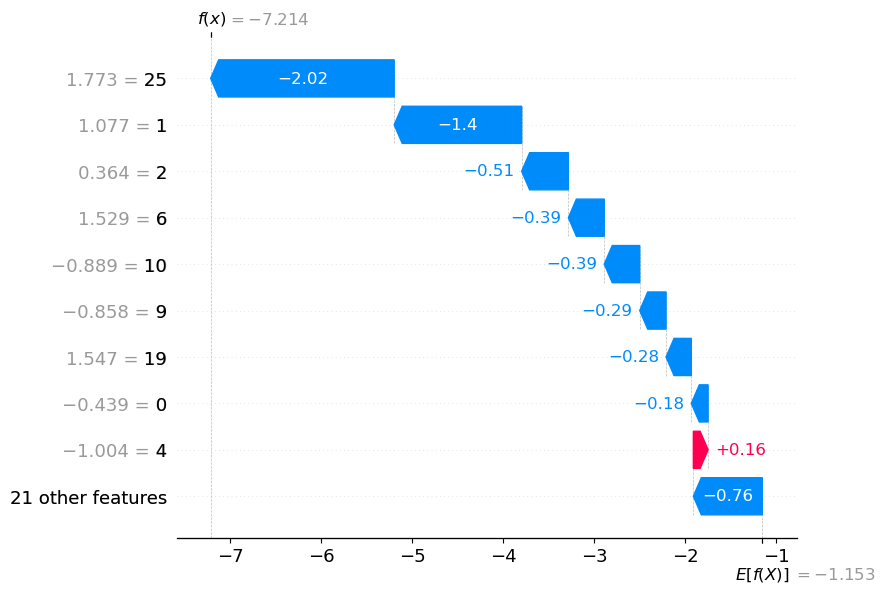

In [12]:
shap.plots.waterfall(shap_values[0])